# Lab 5 – Symulacja VAR(1) i estymatory HC

Celem jest zbadanie przydatności estymatorów heteroskedastycznie zgodnych (HC)
przy estymacji modelu VAR i badaniu przyczynowości w sensie Grangera.

W szczególności:

- dane generujemy z modelu VAR(1),
- przyjmujemy brak przyczynowości (γ₁ = δ₁ = 0),
- estymujemy model klasycznym OLS oraz z wykorzystaniem różnych estymatorów HC,
- analizujemy rozkład estymatorów parametrów oraz rozmiar testów (w tym testu
  przyczynowości od Y_t do X_t).


In [26]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")
SEED = 42

np.random.seed(SEED)

# Parametry DGP VAR(1)
ALPHA_X = 1.0
ALPHA_Y = 1.0
BETA_1 = 0.7  # autokorelacja X_t
THETA_1 = 0.7  # autokorelacja Y_t
GAMMA_1 = 0.0  # brak przyczynowości Y -> X
DELTA_1 = 0.0  # brak przyczynowości X -> Y
SIGMA = 1.0

# Ustawienia symulacji
T = 200  # długość próby użytej do estymacji
BURNIN = 100  # dodatkowe obserwacje do rozgrzania procesu
N_SIM = 1000  # liczba replikacji Monte Carlo
ALPHA = 0.05  # poziom istotności testów

# Rodzaje estymatorów kowariancji: klasyczny i różne HC
HC_TYPES = ["classic", "HC0", "HC1", "HC2", "HC3"]


In [27]:
def simulate_var1(
    T,
    alpha_x,
    alpha_y,
    beta_1,
    gamma_1,
    delta_1,
    theta_1,
    sigma,
    burnin=100,
    rng=None,
):
    """
    Symuluje dane z dwuwymiarowego VAR(1):
        X_t = α_x + β_1 X_{t-1} + γ_1 Y_{t-1} + ε_t
        Y_t = α_y + δ_1 X_{t-1} + θ_1 Y_{t-1} + η_t
    gdzie [ε_t, η_t]' ~ N(0, σ^2 I).

    Zwraca DataFrame z kolumnami 'X', 'Y' o długości T.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_total = T + burnin
    shocks = rng.normal(loc=0.0, scale=sigma, size=(n_total, 2))

    x = np.zeros(n_total)
    y = np.zeros(n_total)

    for t in range(1, n_total):
        x[t] = (
            alpha_x
            + beta_1 * x[t - 1]
            + gamma_1 * y[t - 1]
            + shocks[t, 0]
        )
        y[t] = (
            alpha_y
            + delta_1 * x[t - 1]
            + theta_1 * y[t - 1]
            + shocks[t, 1]
        )

    df = pd.DataFrame({"X": x[burnin:], "Y": y[burnin:]})
    return df


In [28]:
def build_regressions_var1(df):
    """
    Dla danych (X_t, Y_t) buduje macierze regresyjne dla dwóch równań VAR(1):

    X_t = α_x + β_1 X_{t-1} + γ_1 Y_{t-1} + ε_t
    Y_t = α_y + δ_1 X_{t-1} + θ_1 Y_{t-1} + η_t

    Zwraca: y_x, X_x, y_y, X_y.
    """
    df_lag = df.shift(1).dropna()

    # Po przesunięciu, pierwsza obserwacja jest utracona
    y_x = df["X"].iloc[1:]
    y_y = df["Y"].iloc[1:]

    X_lags = df_lag[["X", "Y"]].copy()
    X_lags.columns = ["X_lag", "Y_lag"]

    X_x = sm.add_constant(X_lags)
    X_y = sm.add_constant(X_lags)
    

    return y_x, X_x, y_y, X_y


In [29]:
# Jedna przykładowa realizacja i wybór rzędu VAR na podstawie
# trzech kryteriów informacyjnych.

rng = np.random.default_rng(SEED)
df_example = simulate_var1(
    T=T,
    alpha_x=ALPHA_X,
    alpha_y=ALPHA_Y,
    beta_1=BETA_1,
    gamma_1=GAMMA_1,
    delta_1=DELTA_1,
    theta_1=THETA_1,
    sigma=SIGMA,
    burnin=BURNIN,
    rng=rng,
)

model_example = VAR(df_example)
max_lags = 5
order_selection = model_example.select_order(maxlags=max_lags)
print("Wyniki wyboru rzędu VAR:")
print(order_selection.summary())


Wyniki wyboru rzędu VAR:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       1.057       1.090       2.877       1.070
1    0.07333*     0.1740*      1.076*     0.1141*
2      0.1021      0.2699       1.107      0.1700
3      0.1419      0.3769       1.152      0.2370
4      0.1678      0.4699       1.183      0.2901
5      0.1510      0.5203       1.163      0.3005
-------------------------------------------------


In [30]:
# Przykładowa estymacja równania dla X_t klasycznym OLS oraz
# z wykorzystaniem różnych estymatorów HC.

y_x, X_x, y_y, X_y = build_regressions_var1(df_example)

ols_x = sm.OLS(y_x, X_x).fit()
ols_y = sm.OLS(y_y, X_y).fit()

print("Równanie dla X_t – klasyczne odchylenia standardowe:")
print(ols_x.summary())

for cov_type in ["HC0", "HC1", "HC2", "HC3"]:
    rob_x = ols_x.get_robustcov_results(cov_type=cov_type)
    print(f"\nRównanie dla X_t – estymator {cov_type}:")
    print(rob_x.summary())


Równanie dla X_t – klasyczne odchylenia standardowe:
                            OLS Regression Results                            
Dep. Variable:                      X   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     92.39
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           5.44e-29
Time:                        15:34:48   Log-Likelihood:                -289.60
No. Observations:                 199   AIC:                             585.2
Df Residuals:                     196   BIC:                             595.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [31]:
# Pętla Monte Carlo: estymatory parametrów i p-value dla klasycznych
# oraz HC-odpornych odchyleń standardowych.

true_params = {
    "alpha_x": ALPHA_X,
    "beta_1": BETA_1,
    "gamma_1": GAMMA_1,
    "alpha_y": ALPHA_Y,
    "delta_1": DELTA_1,
    "theta_1": THETA_1,
}

estimates = {hc: [] for hc in HC_TYPES}
pvalues = {hc: [] for hc in HC_TYPES}
causality_rejects = {hc: [] for hc in HC_TYPES}  # test Y -> X (γ_1 = 0)

base_rng = np.random.default_rng(SEED)

def p_value_for_param(beta_hat, beta_true, se, df_resid):
    t_stat = (beta_hat - beta_true) / se
    return 2 * stats.t.sf(np.abs(t_stat), df=df_resid)

for sim in range(N_SIM):
    rng_sim = np.random.default_rng(
        base_rng.integers(0, 1_000_000_000),
    )

    df_sim = simulate_var1(
        T=T,
        alpha_x=ALPHA_X,
        alpha_y=ALPHA_Y,
        beta_1=BETA_1,
        gamma_1=GAMMA_1,
        delta_1=DELTA_1,
        theta_1=THETA_1,
        sigma=SIGMA,
        burnin=BURNIN,
        rng=rng_sim,
    )

    y_x, X_x, y_y, X_y = build_regressions_var1(df_sim)

    ols_x = sm.OLS(y_x, X_x).fit()
    ols_y = sm.OLS(y_y, X_y).fit()

    for hc in HC_TYPES:
        if hc == "classic":
            res_x = ols_x
            res_y = ols_y
        else:
            res_x = ols_x.get_robustcov_results(cov_type=hc)
            res_y = ols_y.get_robustcov_results(cov_type=hc)

        params_x = res_x.params
        bse_x = res_x.bse
        df_x = res_x.df_resid

        params_y = res_y.params
        bse_y = res_y.bse
        df_y = res_y.df_resid
        
        # Zapis estymatorów
        est_record = {
            "alpha_x": params_x[0],
            "beta_1": params_x[1],
            "gamma_1": params_x[2],
            "alpha_y": params_y[0],
            "delta_1": params_y[1],
            "theta_1": params_y[2],
        }
        estimates[hc].append(est_record)
        
        # p-value testów H0: parametr = wartość teoretyczna
        pv_record = {
            "alpha_x": p_value_for_param(
                params_x[0],
                true_params["alpha_x"],
                bse_x[0],
                df_x,
            ),
            "beta_1": p_value_for_param(
                params_x[1],
                true_params["beta_1"],
                bse_x[1],
                df_x,
            ),
            "gamma_1": p_value_for_param(
                params_x[2],
                true_params["gamma_1"],
                bse_x[2],
                df_x,
            ),
            "alpha_y": p_value_for_param(
                params_y[0],
                true_params["alpha_y"],
                bse_y[0],
                df_y,
            ),
            "delta_1": p_value_for_param(
                params_y[1],
                true_params["delta_1"],
                bse_y[1],
                df_y,
            ),
            "theta_1": p_value_for_param(
                params_y[2],
                true_params["theta_1"],
                bse_y[2],
                df_y,
            ),
        }
        pvalues[hc].append(pv_record)

        # Rozmiar testu przyczynowości Y -> X (γ_1 = 0)
        causality_rejects[hc].append(pv_record["gamma_1"] < ALPHA)

print("Symulacja Monte Carlo zakończona.")


Symulacja Monte Carlo zakończona.


In [32]:
# Podsumowanie własności estymatorów i rozmiaru testów.

estimates_df = {hc: pd.DataFrame(records) for hc, records in estimates.items()}
pvalues_df = {hc: pd.DataFrame(records) for hc, records in pvalues.items()}

# Średnie estymaty parametrów
mean_estimates = pd.concat(
    {hc: df.mean() for hc, df in estimates_df.items()},
    axis=1,
)
mean_estimates.columns = HC_TYPES
print(f"Średnie estymaty parametrów (po {N_SIM} replikacjach):")
display(mean_estimates)

true_series = pd.Series(true_params)
bias = mean_estimates.sub(true_series, axis=0)
print("Błąd (średnia estymata - wartość teoretyczna):")
display(bias)

# Empiryczny rozmiar testów (częstość odrzucenia H0, gdy prawdziwa)
rejection_rates = pd.concat(
    {hc: (pvalues_df[hc] < ALPHA).mean() for hc in HC_TYPES},
    axis=1,
)
rejection_rates.columns = HC_TYPES
print("Empiryczne rozmiary testów H0: parametr = wartość teoretyczna:")
display(rejection_rates)

# Rozmiar testu przyczynowości Y -> X (γ_1 = 0)
causality_size = {hc: np.mean(causality_rejects[hc]) for hc in HC_TYPES}
causality_size = pd.Series(causality_size, name="size_Y_to_X")
print("Empiryczny rozmiar testu przyczynowości od Y_t do X_t (γ_1 = 0):")
display(causality_size)


Średnie estymaty parametrów (po 1000 replikacjach):


,classic,HC0,HC1,HC2,HC3
alpha_x,1.067791,1.067791,1.067791,1.067791,1.067791
beta_1,0.681952,0.681952,0.681952,0.681952,0.681952
gamma_1,-0.001327,-0.001327,-0.001327,-0.001327,-0.001327
alpha_y,1.071858,1.071858,1.071858,1.071858,1.071858
delta_1,-0.002042,-0.002042,-0.002042,-0.002042,-0.002042
theta_1,0.679669,0.679669,0.679669,0.679669,0.679669


Błąd (średnia estymata - wartość teoretyczna):


,classic,HC0,HC1,HC2,HC3
alpha_x,0.067791,0.067791,0.067791,0.067791,0.067791
beta_1,-0.018048,-0.018048,-0.018048,-0.018048,-0.018048
gamma_1,-0.001327,-0.001327,-0.001327,-0.001327,-0.001327
alpha_y,0.071858,0.071858,0.071858,0.071858,0.071858
delta_1,-0.002042,-0.002042,-0.002042,-0.002042,-0.002042
theta_1,-0.020331,-0.020331,-0.020331,-0.020331,-0.020331


Empiryczne rozmiary testów H0: parametr = wartość teoretyczna:


,classic,HC0,HC1,HC2,HC3
alpha_x,0.051,0.055,0.051,0.051,0.050
beta_1,0.045,0.047,0.046,0.044,0.043
gamma_1,0.059,0.063,0.061,0.060,0.057
alpha_y,0.058,0.067,0.065,0.064,0.058
delta_1,0.058,0.063,0.061,0.061,0.058
theta_1,0.053,0.064,0.060,0.058,0.055


Empiryczny rozmiar testu przyczynowości od Y_t do X_t (γ_1 = 0):


classic    0.059
HC0        0.063
HC1        0.061
HC2        0.060
HC3        0.057
Name: size_Y_to_X, dtype: float64

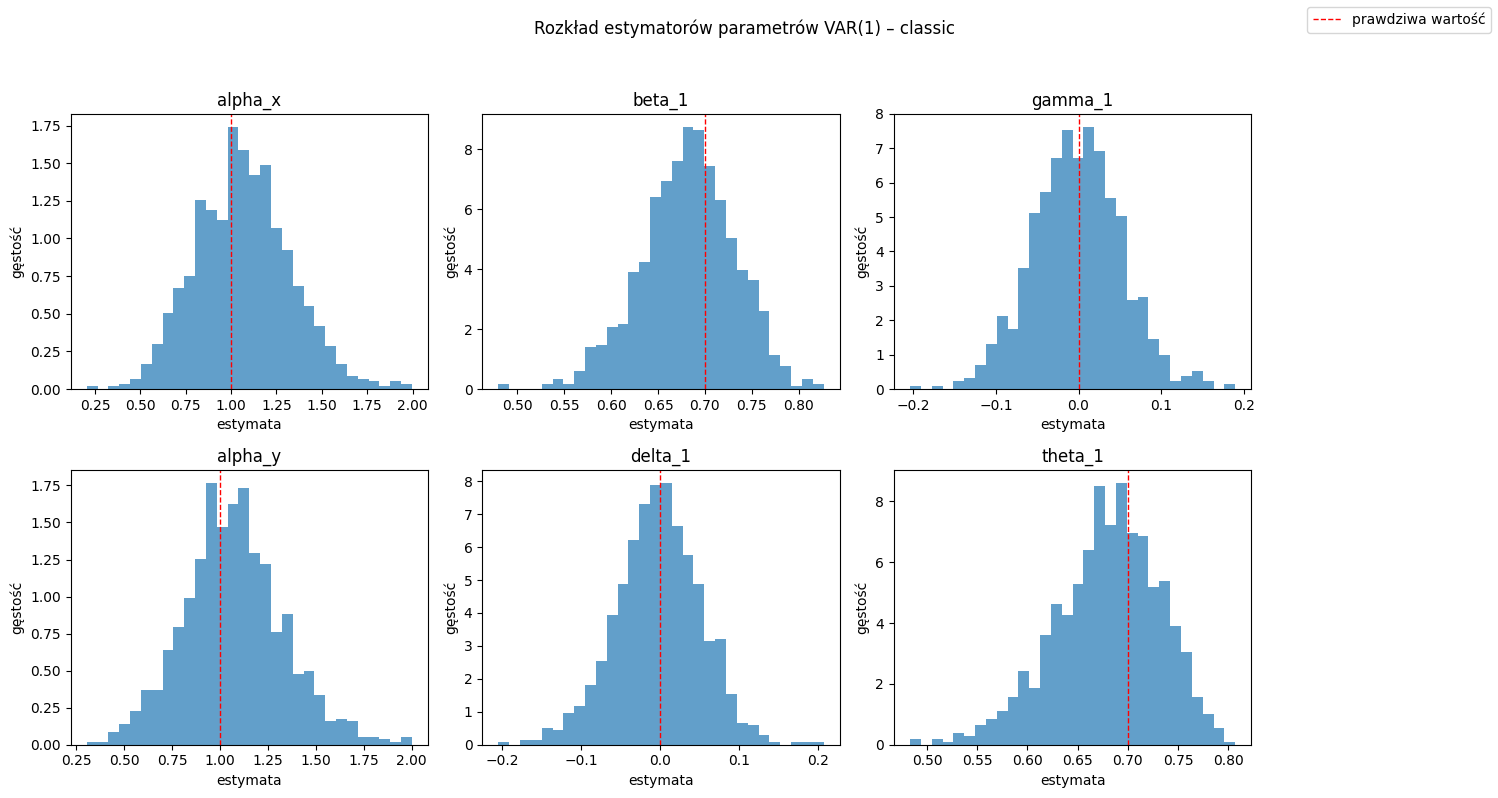

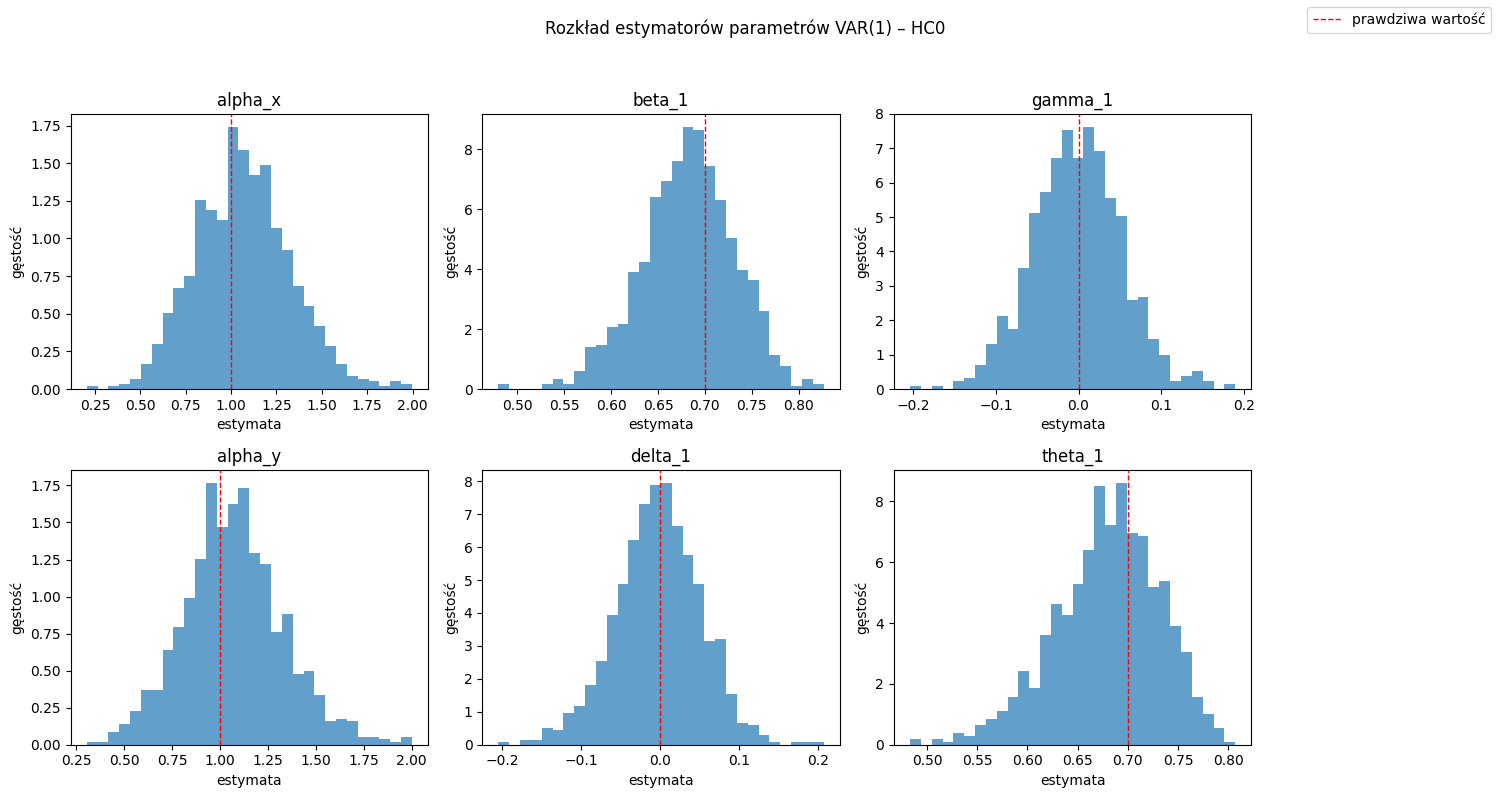

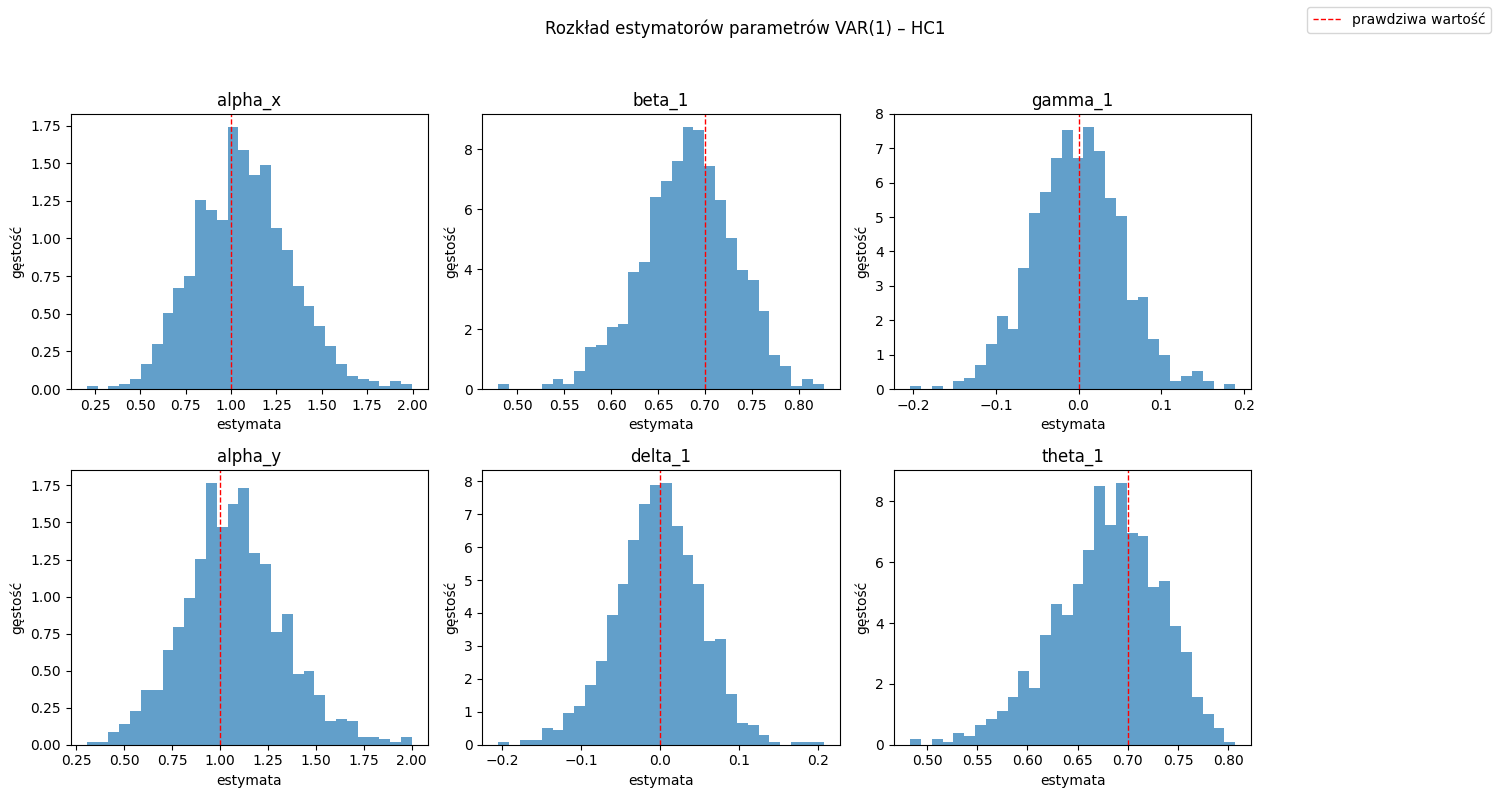

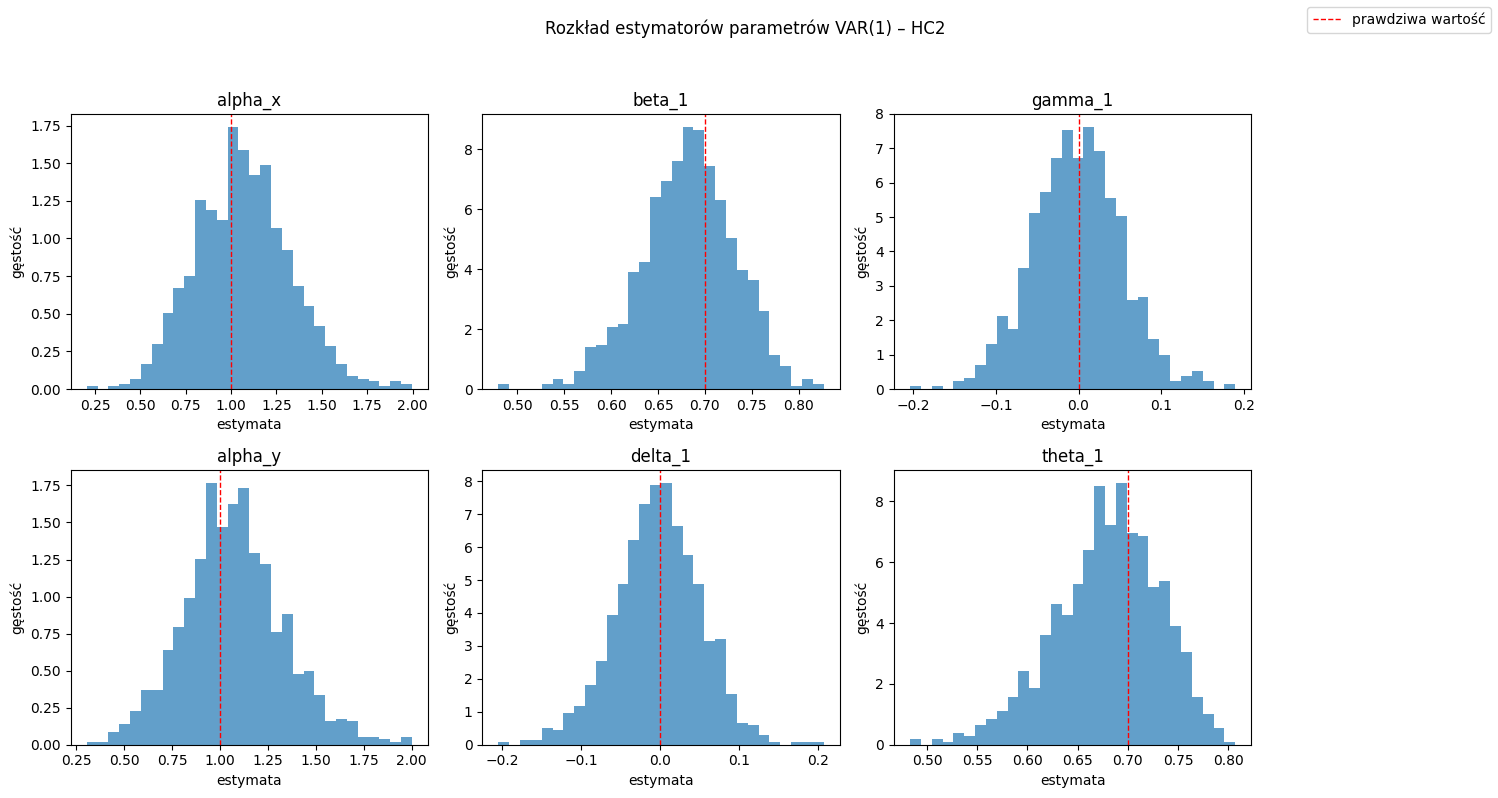

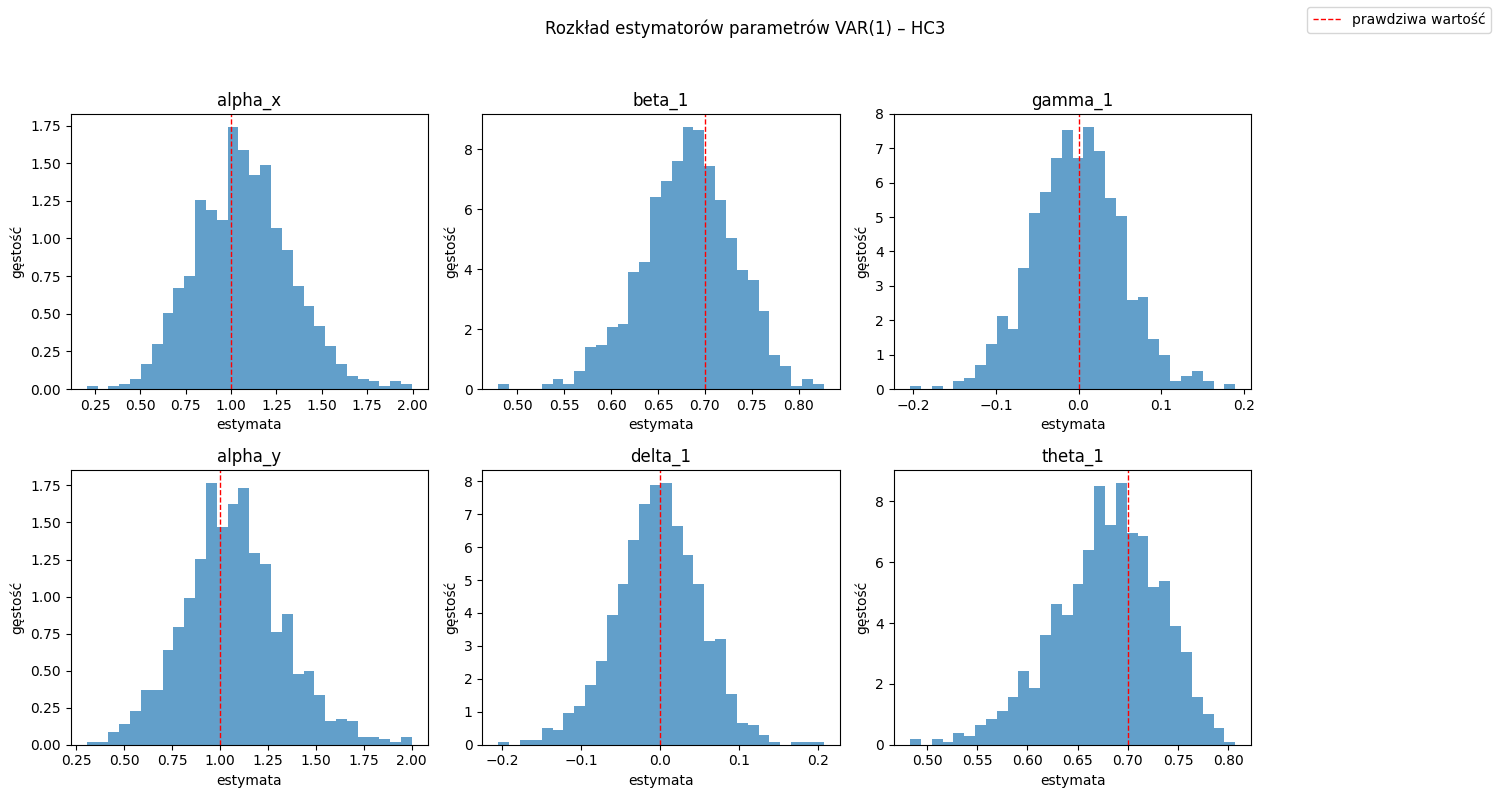

In [33]:
# Wykres 1: rozkład estymatorów parametrów osobno dla każdego estymatora HC
params = ["alpha_x", "beta_1", "gamma_1", "alpha_y", "delta_1", "theta_1"]
true_values = {
    "alpha_x": ALPHA_X,
    "beta_1": BETA_1,
    "gamma_1": GAMMA_1,
    "alpha_y": ALPHA_Y,
    "delta_1": DELTA_1,
    "theta_1": THETA_1,
}
for hc in HC_TYPES:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
    axes = axes.ravel()
    for ax, param in zip(axes, params):
        series = estimates_df[hc][param]
        ax.hist(
            series,
            bins=30,
            density=True,
            alpha=0.7,
            color="tab:blue",
        )
        ax.axvline(
            true_values[param],
            color="red",
            linestyle="--",
            linewidth=1,
            label="prawdziwa wartość" if param == "alpha_x" else None,
        )
        ax.set_title(param)
        ax.set_xlabel("estymata")
        ax.set_ylabel("gęstość")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")
    fig.suptitle(f"Rozkład estymatorów parametrów VAR(1) – {hc}")
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()

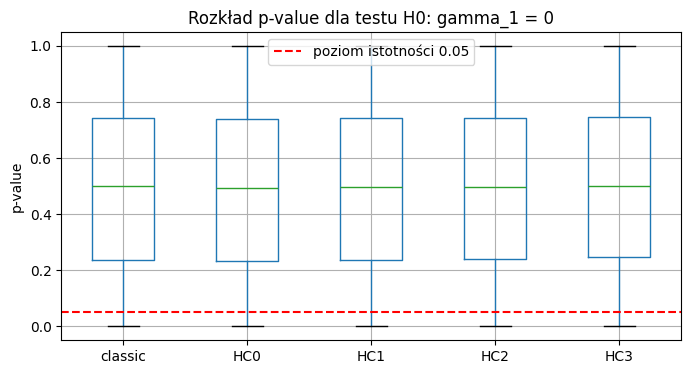

In [34]:
# Wykres 2: rozkład p-value dla gamma_1 (Y -> X) dla różnych estymatorów
pv_gamma = pd.DataFrame(
    {hc: pvalues_df[hc]["gamma_1"] for hc in HC_TYPES}
)
plt.figure(figsize=(8, 4))
pv_gamma.boxplot()
plt.axhline(
    ALPHA,
    color="red",
    linestyle="--",
    label=f"poziom istotności {ALPHA}",
)
plt.title("Rozkład p-value dla testu H0: gamma_1 = 0")
plt.ylabel("p-value")
plt.legend()
plt.show()


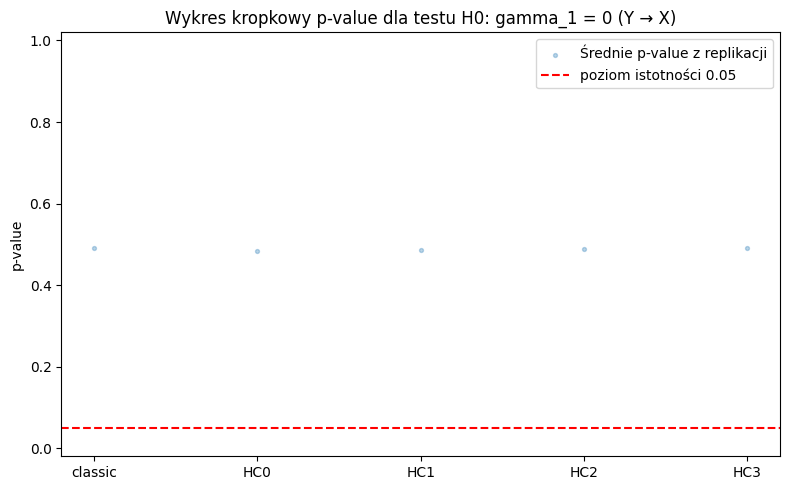

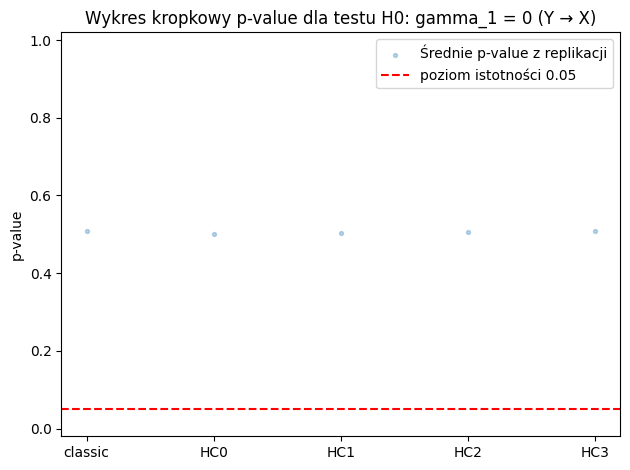

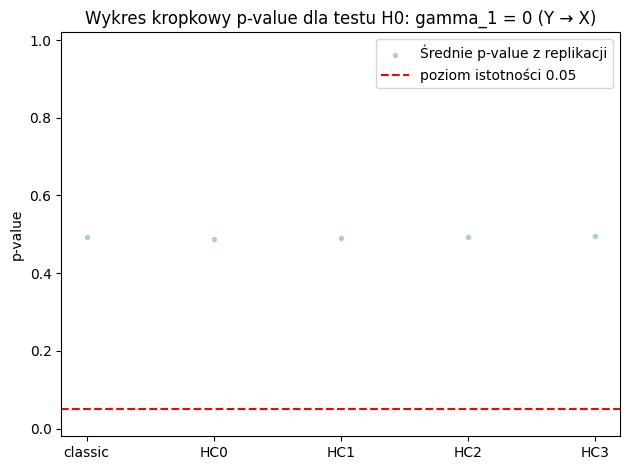

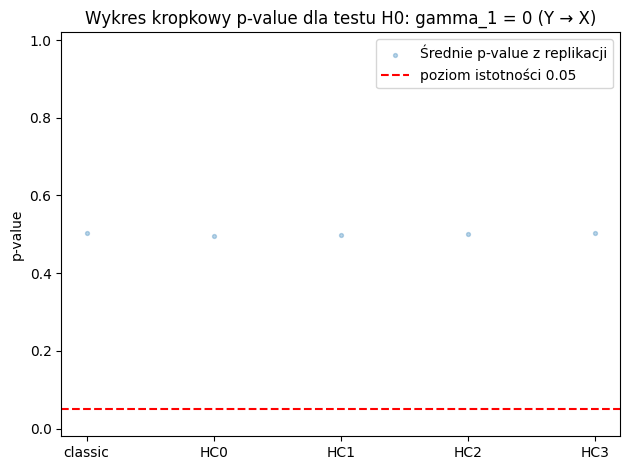

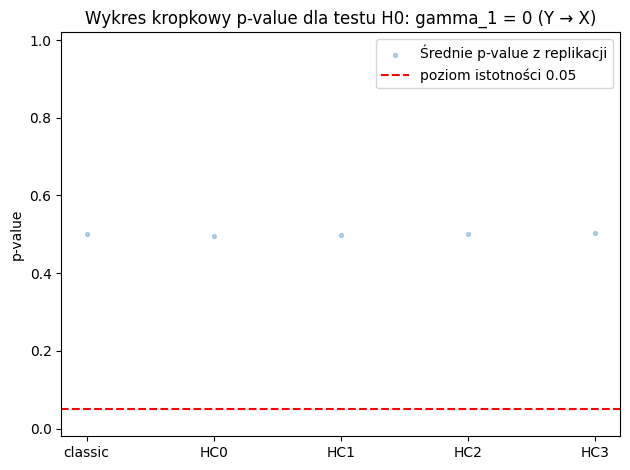

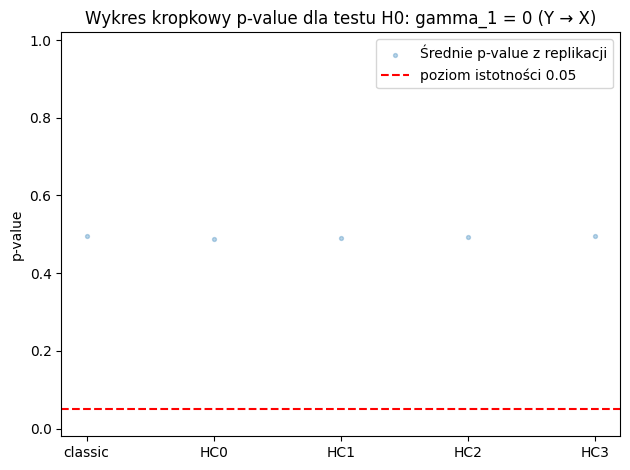

In [ ]:
# Wykres 3: wykres kropkowy (jitter) p-value testu przyczynowości (gamma_1)
# dla różnych estymatorów wariancji
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

for param in params:
    plt.scatter(
        range(len(HC_TYPES)),
        list(map(lambda hc: pvalues_df[hc][param].mean(), HC_TYPES)),
        alpha=0.3,
        s=8,
        label="Średnie p-value z replikacji",
    )
    # pozioma linia na poziomie istotności
    plt.axhline(
        ALPHA,
        color="red",
        linestyle="--",
        label=f"poziom istotności {ALPHA}",
    )
    plt.xticks(range(len(HC_TYPES)), HC_TYPES)
    plt.ylim(-0.02, 1.02)
    plt.ylabel("p-value")
    plt.title(f"Wykres kropkowy p-value dla testu H0: gamma_1 = 0 (Y → X)")
    plt.legend()
    plt.tight_layout()
    plt.show()

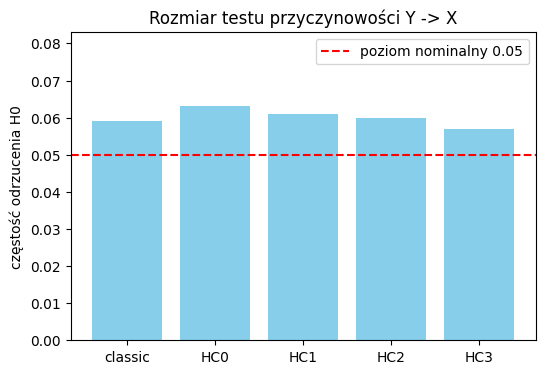

In [36]:
# Wykres 4: empiryczny rozmiar testu przyczynowości Y -> X dla różnych estymatorów
plt.figure(figsize=(6, 4))
plt.bar(causality_size.index, causality_size.values, color="skyblue")
plt.axhline(
    ALPHA,
    color="red",
    linestyle="--",
    label=f"poziom nominalny {ALPHA}",
)
plt.ylim(0, max(causality_size.max() + 0.02, ALPHA + 0.02))
plt.ylabel("częstość odrzucenia H0")
plt.title("Rozmiar testu przyczynowości Y -> X")
plt.legend()
plt.show()


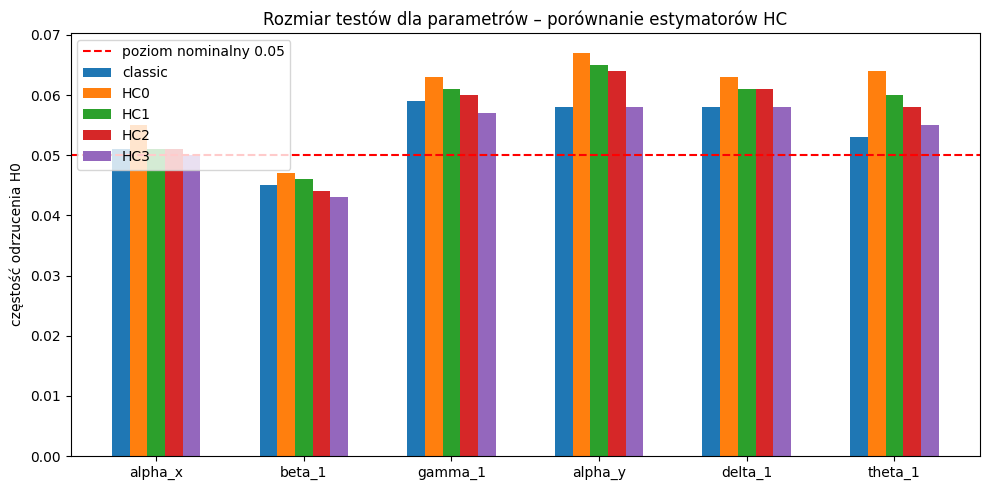

In [37]:
# Wykres 5: porównanie rozmiaru testów dla parametrów (wszystkie estymatory HC)
params_to_show = ["alpha_x", "beta_1", "gamma_1", "alpha_y", "delta_1", "theta_1"]
x = np.arange(len(params_to_show))
width = 0.12
plt.figure(figsize=(10, 5))
for i, hc in enumerate(HC_TYPES):
    plt.bar(
        x + (i - len(HC_TYPES) / 2) * width + width / 2,
        rejection_rates[hc].loc[params_to_show],
        width,
        label=hc,
    )
plt.axhline(
    ALPHA,
    color="red",
    linestyle="--",
    label=f"poziom nominalny {ALPHA}",
)
plt.xticks(x, params_to_show)
plt.ylabel("częstość odrzucenia H0")
plt.title("Rozmiar testów dla parametrów – porównanie estymatorów HC")
plt.legend()
plt.tight_layout()
plt.show()

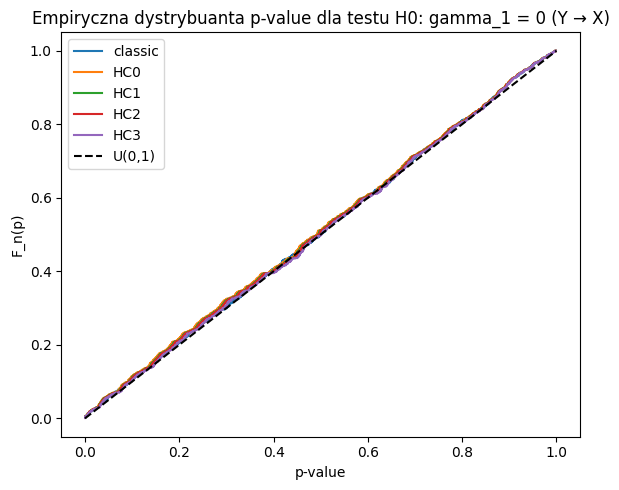

In [38]:
# Wykres 6: empiryczna dystrybuanta p-value dla testu H0: gamma_1 = 0
plt.figure(figsize=(6, 5))
for hc in HC_TYPES:
    pvals = np.sort(pvalues_df[hc]["gamma_1"].values)
    n = len(pvals)
    ecdf = np.arange(1, n + 1) / n
    plt.step(pvals, ecdf, where="post", label=hc)
# linia teoretyczna dla rozkładu jednostajnego U(0,1)
grid = np.linspace(0, 1, 200)
plt.plot(grid, grid, "k--", label="U(0,1)")
plt.xlabel("p-value")
plt.ylabel("F_n(p)")
plt.title("Empiryczna dystrybuanta p-value dla testu H0: gamma_1 = 0 (Y → X)")
plt.legend()
plt.tight_layout()
plt.show()